# Libraries

In [1]:
import random
import math
import matplotlib.pyplot as plt
import seaborn as sns

# Important Initial Parameters

In [2]:
GRID_SIZE = 50
TIMESTEPS = 200

PREY_REPRODUCTION_CHANCE = 0.15

INITIAL_PREDATOR_ENERGY = 8
PREDATOR_REPRODUCTION_ENERGY = 12
PREDATOR_ENERGY_GAIN = 5

# World Wrap

In [3]:
"""
The simulation uses a wrapped (toroidal) 50x50 grid world.
If an agent moves beyond one edge of the grid, it reappears
on the opposite side. This design avoids unrealistic border
effects and ensures agents have equal movement opportunities
throughout the environment.

"""


def wrap_position(x, y):
    return x % GRID_SIZE, y % GRID_SIZE


def toroidal_distance(x1, y1, x2, y2):
    dx = min(abs(x1 - x2), GRID_SIZE - abs(x1 - x2))
    dy = min(abs(y1 - y2), GRID_SIZE - abs(y1 - y2))
    return math.sqrt(dx**2 + dy**2)


In [4]:

# BASE AGENT CLASS

class Agent:

    def __init__(self, x, y):
        self.x = x
        self.y = y

    def position(self):
        return (self.x, self.y)

# PREY CLASS

In [5]:

class Prey(Agent):

    def sense_predators(self, predators):

        visible = []

        for predator in predators:

            # Same row
            if predator.x == self.x:
                dist = min(
                    abs(predator.y - self.y),
                    GRID_SIZE - abs(predator.y - self.y)
                )

                if dist <= 3:
                    visible.append(predator)

            # Same column
            elif predator.y == self.y:
                dist = min(
                    abs(predator.x - self.x),
                    GRID_SIZE - abs(predator.x - self.x)
                )

                if dist <= 3:
                    visible.append(predator)

        return visible

    def move(self, predators):

        visible_predators = self.sense_predators(predators)

        possible_moves = []

        for dx in [-1, 0, 1]:
            for dy in [-1, 0, 1]:

                if dx == 0 and dy == 0:
                    continue

                nx, ny = wrap_position(self.x + dx, self.y + dy)
                possible_moves.append((nx, ny))


        # RANDOM MOVEMENT IF NO PREDATORS


        if not visible_predators:
            self.x, self.y = random.choice(possible_moves)
            return


        # MOVE AWAY FROM PREDATORS

        best_moves = []
        max_distance = -1

        for move in possible_moves:

            distances = []

            for predator in visible_predators:
                d = toroidal_distance(
                    move[0], move[1],
                    predator.x, predator.y
                )
                distances.append(d)

            nearest_predator_distance = min(distances)

            if nearest_predator_distance > max_distance:
                max_distance = nearest_predator_distance
                best_moves = [move]

            elif nearest_predator_distance == max_distance:
                best_moves.append(move)

        self.x, self.y = random.choice(best_moves)

# PREDATOR CLASS

In [6]:

class Predator(Agent):

    def __init__(self, x, y, energy=INITIAL_PREDATOR_ENERGY):
        super().__init__(x, y)
        self.energy = energy

    def sense_prey(self, prey_list):

        visible = []

        for prey in prey_list:

            # Same row
            if prey.x == self.x:
                dist = min(
                    abs(prey.y - self.y),
                    GRID_SIZE - abs(prey.y - self.y)
                )

                if dist <= 3:
                    visible.append(prey)

            # Same column
            elif prey.y == self.y:
                dist = min(
                    abs(prey.x - self.x),
                    GRID_SIZE - abs(prey.x - self.x)
                )

                if dist <= 3:
                    visible.append(prey)

        return visible

    def move(self, prey_list):

        visible_prey = self.sense_prey(prey_list)

        # Predator can move 1 or 2 cells
        possible_moves = []

        for dx in [-2, -1, 0, 1, 2]:
            for dy in [-2, -1, 0, 1, 2]:

                if dx == 0 and dy == 0:
                    continue

                # limit movement to max 2 fields
                if max(abs(dx), abs(dy)) <= 2:

                    nx, ny = wrap_position(self.x + dx, self.y + dy)
                    possible_moves.append((nx, ny, dx, dy))


        # RANDOM MOVEMENT IF NO PREY


        if not visible_prey:

            move = random.choice(possible_moves)

            self.x, self.y = move[0], move[1]

            movement_cost = max(abs(move[2]), abs(move[3]))
            self.energy -= movement_cost

            return


        # MOVE TOWARD CLOSEST PREY


        best_moves = []
        min_distance = float("inf")

        for move in possible_moves:

            distances = []

            for prey in visible_prey:
                d = toroidal_distance(
                    move[0], move[1],
                    prey.x, prey.y
                )
                distances.append(d)

            closest_prey_distance = min(distances)

            if closest_prey_distance < min_distance:
                min_distance = closest_prey_distance
                best_moves = [move]

            elif closest_prey_distance == min_distance:
                best_moves.append(move)

        chosen = random.choice(best_moves)

        self.x, self.y = chosen[0], chosen[1]

        movement_cost = max(abs(chosen[2]), abs(chosen[3]))
        self.energy -= movement_cost

# SIMULATION CLASS


Running SET A - Run 1


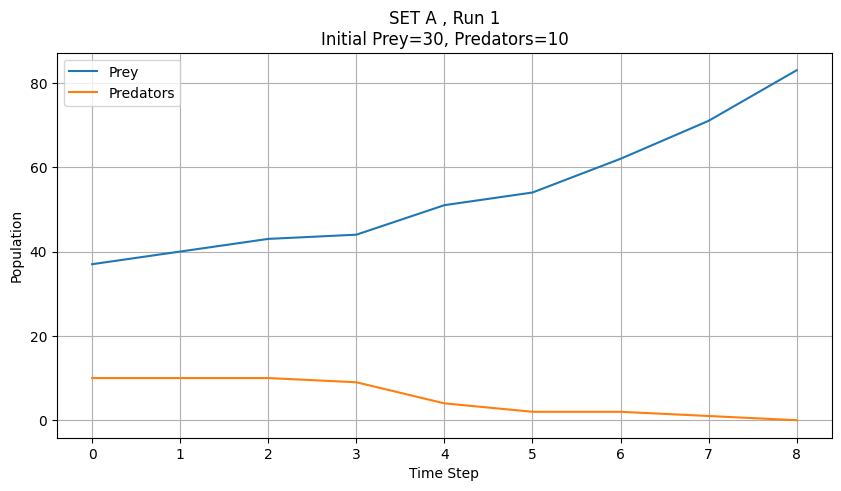


Running SET A - Run 2


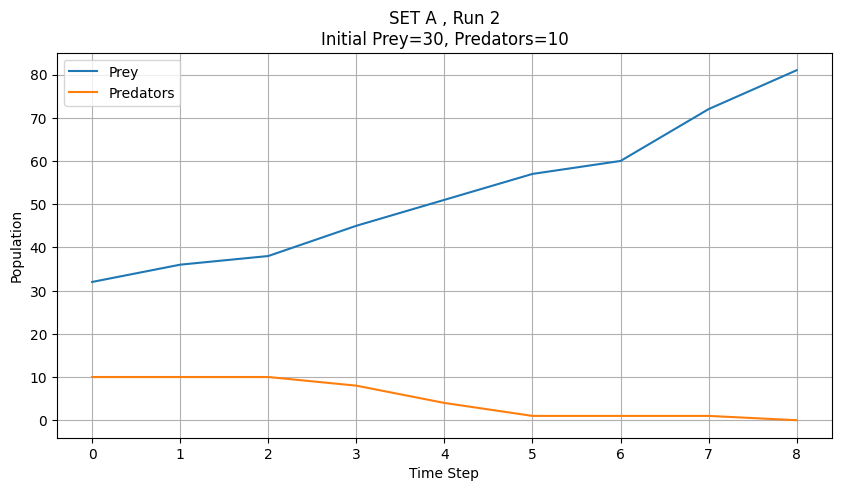


Running SET A - Run 3


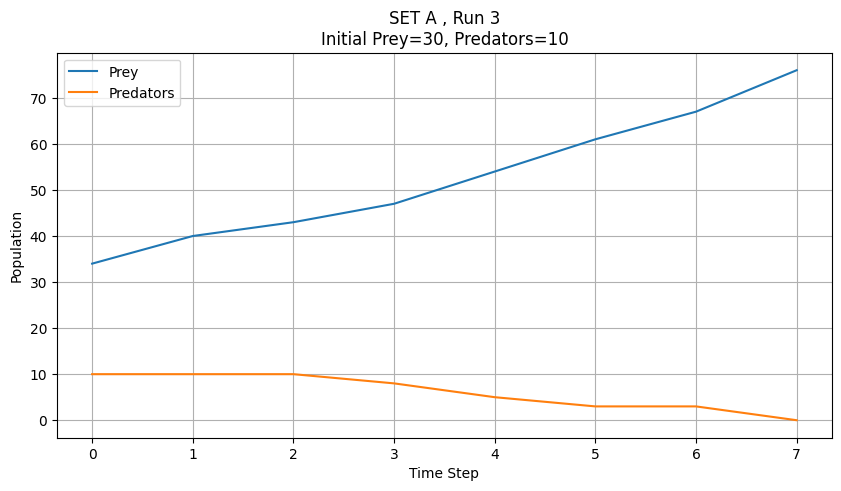


Running SET B - Run 1


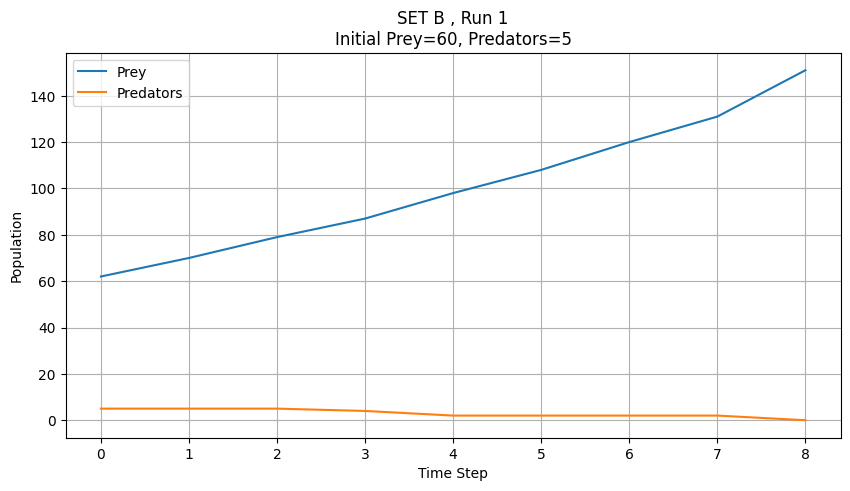


Running SET B - Run 2


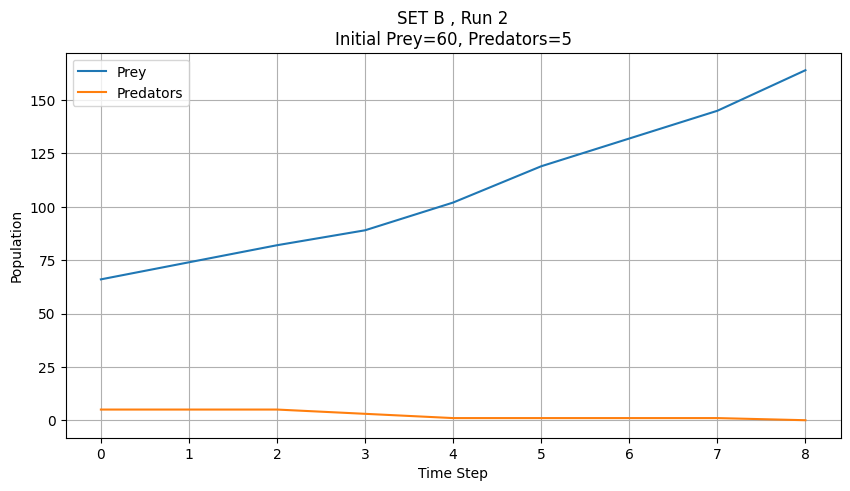


Running SET B - Run 3


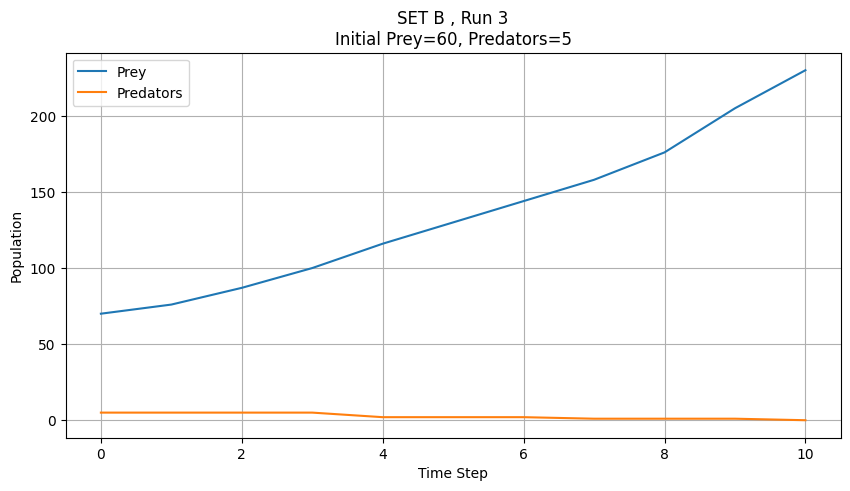

In [7]:

class Simulation:

    def __init__(self, initial_prey, initial_predators):

        self.prey_list = []
        self.predator_list = []

        self.prey_population_history = []
        self.predator_population_history = []

        occupied_positions = set()

        # SPAWN PREY
        while len(self.prey_list) < initial_prey:

            x = random.randint(0, GRID_SIZE - 1)
            y = random.randint(0, GRID_SIZE - 1)

            if (x, y) not in occupied_positions:
                self.prey_list.append(Prey(x, y))
                occupied_positions.add((x, y))

        # SPAWN PREDATORS

        while len(self.predator_list) < initial_predators:

            x = random.randint(0, GRID_SIZE - 1)
            y = random.randint(0, GRID_SIZE - 1)

            if (x, y) not in occupied_positions:
                self.predator_list.append(Predator(x, y))
                occupied_positions.add((x, y))

    # MOVEMENT PHASE

    def movement_phase(self):

        # Prey movement
        for prey in self.prey_list:
            prey.move(self.predator_list)

        # Predator movement
        for predator in self.predator_list:
            predator.move(self.prey_list)

        # Remove dead predators
        self.predator_list = [
            predator
            for predator in self.predator_list
            if predator.energy > 0
        ]

    # INTERACTION PHASE

    def interaction_phase(self):

        remaining_prey = self.prey_list.copy()

        for predator in self.predator_list:

            prey_on_same_cell = [
                prey
                for prey in remaining_prey
                if prey.position() == predator.position()
            ]

            if prey_on_same_cell:

                eaten_prey = random.choice(prey_on_same_cell)

                remaining_prey.remove(eaten_prey)

                predator.energy += PREDATOR_ENERGY_GAIN

        self.prey_list = remaining_prey


    # REPRODUCTION PHASE

    def reproduction_phase(self):

        new_prey = []
        new_predators = []

        # PREY REPRODUCTION

        for prey in self.prey_list:

            if random.random() < PREY_REPRODUCTION_CHANCE:

                dx = random.choice([-1, 0, 1])
                dy = random.choice([-1, 0, 1])

                if dx == 0 and dy == 0:
                    continue

                nx, ny = wrap_position(prey.x + dx, prey.y + dy)

                new_prey.append(Prey(nx, ny))

        # PREDATOR REPRODUCTION

        for predator in self.predator_list:

            if predator.energy >= PREDATOR_REPRODUCTION_ENERGY:

                dx = random.choice([-1, 0, 1])
                dy = random.choice([-1, 0, 1])

                if dx == 0 and dy == 0:
                    continue

                nx, ny = wrap_position(
                    predator.x + dx,
                    predator.y + dy
                )

                new_predators.append(Predator(nx, ny))

                # reproduction energy cost
                predator.energy -= 6

        self.prey_list.extend(new_prey)
        self.predator_list.extend(new_predators)

    # RECORDING POPULATIONS

    def record_populations(self):

        self.prey_population_history.append(len(self.prey_list))
        self.predator_population_history.append(
            len(self.predator_list)
        )

    # FUNCTION FOR RUNNING SIMULATION

    def run(self, timesteps=TIMESTEPS):

        for _ in range(timesteps):

            if len(self.prey_list) == 0:
                break

            if len(self.predator_list) == 0:
                break

            self.movement_phase()

            self.interaction_phase()

            self.reproduction_phase()

            self.record_populations()

        return (
            self.prey_population_history,
            self.predator_population_history
        )


# PLOTTING FUNCTION

def plot_simulation(prey_history,
                    predator_history,
                    title):

    plt.figure(figsize=(10, 5))

    plt.plot(prey_history, label="Prey")
    plt.plot(predator_history, label="Predators")

    plt.xlabel("Time Step")
    plt.ylabel("Population")
    plt.title(title)

    plt.legend()

    plt.grid(True)


    plt.show()


# FUNCTION FOR RUNNING EXPERIMENTS

def run_experiment_set(prey_count,
                       predator_count,
                       set_name):

    for run_number in range(1, 4):

        print(
            f"\nRunning {set_name} - "
            f"Run {run_number}"
        )

        simulation = Simulation(
            initial_prey=prey_count,
            initial_predators=predator_count
        )

        prey_history, predator_history = simulation.run()

        plot_simulation(
            prey_history,
            predator_history,
            title=(
                f"{set_name} , "
                f"Run {run_number}\n"
                f"Initial Prey={prey_count}, "
                f"Predators={predator_count}"
            )
        )


# EXPERIMENT SET A
# Balanced Ecosystem

run_experiment_set(
    prey_count=30,
    predator_count=10,
    set_name="SET A"
)

# EXPERIMENT SET B
# Prey-Dominant Ecosystem

run_experiment_set(
    prey_count=60,
    predator_count=5,
    set_name="SET B"
)